segment_agland.py -- James Sayre, sayrejay@pm.me

Intersect ADCs with agmask information.

In [ ]:
### Programs
import os, sys
os.environ['USE_PYGEOS'] = '0'
import regionmask
import geopandas as gpd, fiona
fiona.drvsupport.supported_drivers['libkml'] = 'rw' # enable KML support which is disabled by default
fiona.drvsupport.supported_drivers['LIBKML'] = 'rw' # enable KML support which is disabled by default
import xarray as xr
from shapely.geometry import Polygon
from shapely.geometry import Point
from shapely.ops import cascaded_union
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Directories
topdir             =  "/home/j/Dropbox/Projects/"
projectdir         =  os.path.join(topdir,     "Maize_prediction")
cropdir            =  os.path.join(topdir,    "Crop_misallocation")
sciagadir          =  os.path.join(cropdir,   "data", "SCIAGA")
datadir            =  os.path.join(projectdir, "Data")
agland_dir         =  os.path.join(datadir,    "SIAP_agland", "Input")
agland_out_dir     =  os.path.join(datadir,    "SIAP_agland", "Output")
maize_dir          =  os.path.join(datadir,    "SIAP_maize_land", "Input")
maize_out_dir      =  os.path.join(datadir,    "SIAP_maize_land", "Output")
mexico_dir         =  os.path.join(datadir,    "Mexico_agland","Outputs")
inegi_dir          =  os.path.join(datadir,    "INEGI")
amcadir            =  os.path.join(inegi_dir,  "Areas_Censal_Agropecuario_2016")
md_dir             =  os.path.join(inegi_dir,  "MD_lab_outputs", "AMCA_ADC_data_2022-11-23")

### Inputs
adcshp             =  os.path.join(os.path.expanduser("~"), "Dropbox", "Projects", "Maize_prediction", "Data", "Shapefiles", "adc_shapefile.shp")
ca2016adc          =  os.path.join(amcadir,    "census_areas.shp")
ca2007mun          =  os.path.join(sciagadir,  "CA2007_mun_fromadc_poly.shp")
ca2016mun          =  os.path.join(amcadir,    "muns_from_ADC16_areas.shp")
amca_data          =  os.path.join(md_dir,     "amca_sup_adc.csv")
inegi_agland_mun16 =  os.path.join(mexico_dir, "inegi_agland_16_mun.shp")
inegi_agland_adc16 =  os.path.join(mexico_dir, "inegi_agland_16_adc.shp")
inegi_agland_adc07 =  os.path.join(mexico_dir, "inegi_agland_07_adc.shp") 
agland_fls         =  os.listdir(agland_dir)
maize_fls          =  os.listdir(maize_dir)

### Intermediates
mun_key_fl         =  os.path.join(maize_out_dir, "mun_key.csv")
mun_key_match_fl   =  os.path.join(maize_out_dir, "mun_key_match.csv")
        
### Outputs
maize_mun16_fl     =  os.path.join(maize_out_dir,  "maize_land_mun16.shp")
maize_mun07_fl     =  os.path.join(maize_out_dir,  "maize_land_mun07.shp")
maize_adc16_fl     =  os.path.join(maize_out_dir,  "maize_adc16.shp")
maize_adc07_fl     =  os.path.join(maize_out_dir,  "maize_adc07.shp")
sorgo_out_fl       =  os.path.join(maize_out_dir,  "sorghum_land.shp")
bean_out_fl        =  os.path.join(maize_out_dir,  "bean_land.shp")
wheat_out_fl       =  os.path.join(maize_out_dir,  "wheat_land.shp")
agland_shp_siap    =  os.path.join(agland_out_dir, "agland_siap.shp")
agland_shp_cader   =  os.path.join(agland_out_dir, "agland_cader.shp")
agland_adc16       =  os.path.join(agland_out_dir, "agland_adc16.shp")
agland_mun16       =  os.path.join(agland_out_dir, "agland_mun16.shp")
agland_mun07       =  os.path.join(agland_out_dir, "agland_mun07.shp")
agland_adc07       =  os.path.join(agland_out_dir, "agland_adc07.shp")

adc_land_area_07   =  os.path.join(agland_out_dir, "2007_adcs_agland_area.csv")
adc_land_area_16   =  os.path.join(agland_out_dir, "2016_adcs_agland_area.csv")

In [2]:
### Now merge with mun
### Municipality shapefiles
mun07_df = gpd.read_file(ca2007mun)
mun16_df = gpd.read_file(ca2016mun)[['muncode','geometry']]
mun16_df = mun16_df.set_crs(mun07_df.crs)

### Read in 2007 Area de Control information
adc07_df = gpd.read_file(adcshp)
adc07_df = adc07_df[~adc07_df['adcid'].isna()]
adc07_df = adc07_df[['adcid','tablaAlias','geometry']]
adc07_df.columns = ['adc07','adc07_type','geometry']
adc07_df.set_geometry('geometry', inplace=True)
adc07_df['muncode'] = adc07_df['adc07'].apply(lambda x: x[:5])
adc07_df['cve_ent'] = adc07_df['adc07'].apply(lambda x: x[:2])

### Read in AMCA 2016 ADC info
adc16_df = gpd.read_file(ca2016adc)
adc16_df = adc16_df[['CONTROL','geometry']]
adc16_df.columns = ['adc16','geometry']
adc16_df.set_geometry('geometry', inplace=True)
adc16_df = adc16_df.set_crs(adc07_df.crs)
adc16_df['muncode'] = adc16_df['adc16'].apply(lambda x: x[:5])
adc16_df['cve_ent'] = adc16_df['adc16'].apply(lambda x: x[:2])


In [3]:
### Code for maize agland
selec_cult = 'Maíz grano' ### 'Sorgo grano' ### 'Frijol' ### 'Trigo grano'
selec_year = 2007

full_df = gpd.GeoDataFrame()
for fl in sorted(maize_fls,reverse=False):
    if fl.endswith('.kmz'):
        st_name = fl.split('PV2015_')[1].split('.kmz')[0]
        if selec_year == 2016:
            out_fl = os.path.join(maize_out_dir, st_name + '_maize_adc16.shp')
        elif selec_year == 2007:
            out_fl = os.path.join(maize_out_dir, st_name + '_maize_adc07.shp')
        if not os.path.exists(out_fl):
            print(st_name)
            fl_path = os.path.join(maize_dir, fl)
            df = gpd.read_file(fl_path)[['description','geometry']]
            df['mun']     = df['description'].apply(lambda x: x.split('<td>NOM_MUN</td>\n\n<td>')[1].split('</td>\n\n</tr>\n\n')[0])
            df['cultivo'] = df['description'].apply(lambda x: x.split('<td>CULTIVO</td>\n\n<td>')[1].split('</td>\n\n</tr>\n\n<tr>')[0])
            df['est']     = df['description'].apply(lambda x: x.split('<td>DELEGACIÓN</td>\n\n<td>')[1].split('</td>\n\n</tr>\n\n</table>')[0])
            df.drop('description', axis=1, inplace=True)
            maize_df = df[df['cultivo'] == selec_cult].drop(['cultivo','mun'],axis=1).dissolve('est').reset_index()
            if selec_year == 2016:
                maize_df = gpd.overlay(adc16_df.drop(['muncode','cve_ent'],axis=1), maize_df, how='intersection') ### 2016
            elif selec_year == 2007:
                maize_df = gpd.overlay(adc07_df.drop(['muncode','cve_ent','adc07_type'],axis=1), maize_df, how='intersection') ### 2007
            maize_df.to_file(out_fl, write_index=False)
        else:
            maize_df = gpd.read_file(out_fl)
        full_df = pd.concat([full_df, maize_df]).reset_index(drop=True)

if selec_year == 2016:
    full_df = full_df.dissolve('adc16').reset_index() ### 2016
    full_df['maize_land'] = full_df.to_crs(epsg=6372).geometry.area/10000.0
    full_df.to_file(maize_adc16_fl, write_index=False) ### 2016
    ## Now write to municipality maize land shapefile
    full_df['muncode'] = full_df['adc16'].apply(lambda x: x[:5])
    full_df = full_df.dissolve('muncode').reset_index()
    full_df = full_df.drop(['maize_land','adc16'], axis=1)
    full_df.to_file(maize_mun16_fl, write_index=False)
elif selec_year == 2007:
    full_df = full_df.dissolve('adc07').reset_index() ### 2007
    full_df['maize_land'] = full_df.to_crs(epsg=6372).geometry.area/10000.0
    full_df = full_df.drop('est', axis=1)
    full_df.to_file(maize_adc07_fl, write_index=False) ### 2007
    ### Now write to municipality maize land shapefile
    full_df['muncode'] = full_df['adc07'].apply(lambda x: x[:5])
    full_df = full_df.dissolve('muncode').reset_index()
    full_df = full_df.drop(['adc07','maize_land'], axis =1)
    full_df.to_file(maize_mun07_fl, write_index=False)

# sorgo_out_fl, bean_out_fl, wheat_out_fl

In [3]:
### Compare maize shapefile to AMCA information
full_df = gpd.read_file(maize_adc_out_fl)
full_df['num_polys'] = full_df.geometry.apply(lambda x: len(list(x.geoms)) if x.geom_type == 'MultiPolygon' else 1)
full_df = full_df.drop('geometry', axis=1)

amca_df = pd.read_csv(amca_data)
amca_df = amca_df[amca_df['name'] == 'Maize']
amca_df = amca_df[['adc', 'name', 'super_cart', 'sup_sem',
       'sup_irrig', 'sup_rf', 'num_terrenos']]
amca_df.columns = ['adc16', 'name', 'super_cart', 'sup_sem',
       'sup_irrig', 'sup_rf', 'num_terrenos']
amca_df['num_terrenos'] = amca_df['num_terrenos'].apply(lambda x: 2 if x == "*" else x)

full_df = full_df.merge(amca_df, on = 'adc16', how='outer')

In [4]:
print("AMCA reports {} ha of maize".format(round(full_df['sup_sem'].sum())))
print("Maize estimation reports {} ha of maize".format(round(full_df['maize_land_area'].sum())))
print("There is a {}% more maize reported by AMCA".format(round((full_df['sup_sem'].sum()/full_df['maize_land_area'].sum() - 1)*100)))

AMCA reports 8079395 ha of maize
Maize estimation reports 3633877 ha of maize
There is a 122% more maize reported by AMCA


In [23]:
overlap_df = full_df[~full_df['sup_sem'].isna() & ~full_df['maize_land_area'].isna()]

r2_score(overlap_df['maize_land_area'], overlap_df['sup_sem']), r2_score(overlap_df['num_polys'], overlap_df['num_terrenos'])


-1.4718584270713109

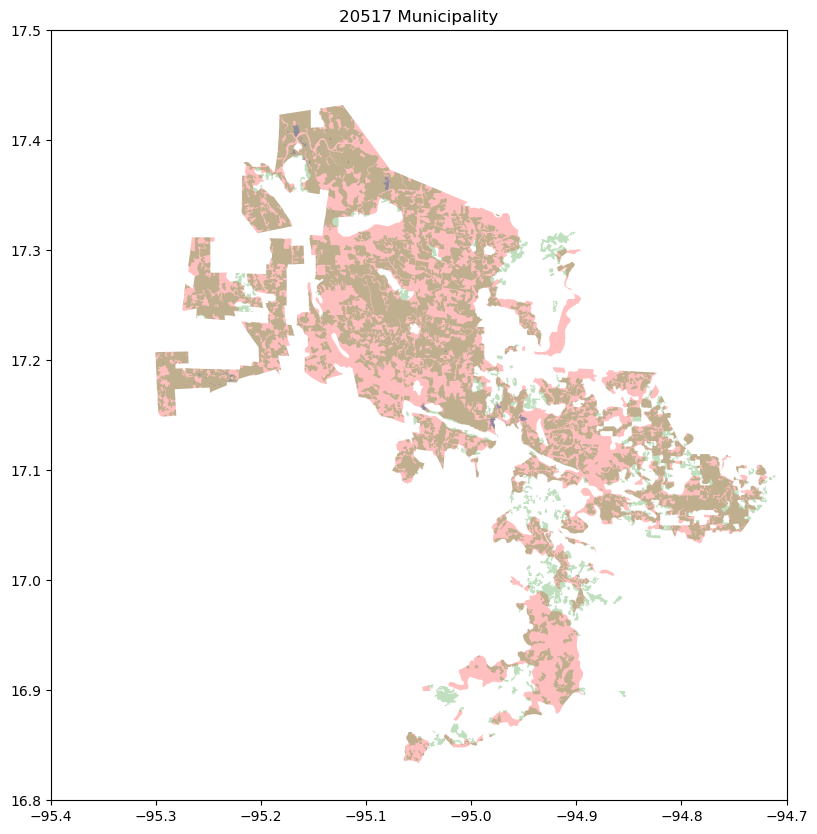

<Figure size 640x480 with 0 Axes>

In [27]:
### Plot SIAP agland, INEGI agland, and SIAP maize land for one municipality
amca_df['muncode'] = amca_df['adc16'].apply(lambda x: x[:5])
amca_maize_df = amca_df[amca_df['muncode'] == '20057']

amca_maize_df = amca_maize_df.merge(adc16_df, on='adc16', how='left')
amca_maize_df = gpd.GeoDataFrame(amca_maize_df)

### INEGI agland
mex_agland_df = gpd.read_file(inegi_agland_mun16)
mex_agland_df = mex_agland_df[mex_agland_df['muncode'] == '20057']

### SIAP maize land
full_20057_df = gpd.read_file(maize_out_fl)
full_20057_df = full_20057_df[full_20057_df['muncode'] == '20057']

### SIAP agland
siap_agland_df = gpd.read_file(agland_mun16)
siap_agland_df = siap_agland_df[siap_agland_df['muncode'] == '20057']


fig, ax = plt.subplots(figsize=(10, 10))

# Set the latitude and longitude limits
ax.set_xlim(-95.4, -94.7)
ax.set_ylim(16.8, 17.5)

# Plot the GeoPandas dataframes
# mun16_20057_df.plot(ax=ax, color='black', alpha=0.25, label='Municipality',  legend=True)
mex_agland_df.plot(ax=ax, color='red', alpha=0.25, label='INEGI Agland',  legend=True)
full_20057_df.plot(ax=ax, color='blue', alpha=0.25, label='SIAP Maize Land', legend=True)
siap_agland_df.plot(ax=ax, color='green', alpha=0.25, label='SIAP Agland', legend=True)
# amca_maize_df.plot(ax=ax, color='green', alpha=0.25, label='AMCA areas with maize', legend=True)
# Add the other two dataframes here

# Add legend
# plt.legend()

plt.title('20517 Municipality')

# Show the plot
plt.show()
plt.savefig(os.path.join(maize_out_dir, 'mun_20057.png'), dpi=300)

In [3]:
mun_cader_cntry = "mun16" ### "mun16" ### "cader" ### "mun07"
if mun_cader_cntry == "mun16":
    mun_shapefile = mun16_df
elif mun_cader_cntry == "mun07":
    mun_shapefile = mun07_df

### Code for agland
full_df, cader_df = gpd.GeoDataFrame(), gpd.GeoDataFrame()
for fl in agland_fls:
    if fl.endswith('.kmz'):
        # if "Son_Sin" in fl:
        print(fl)
        fl_path = os.path.join(agland_dir, fl)
        df = gpd.read_file(fl_path)[['description','geometry']]
        df['cve_ent']     = df['description'].apply(lambda x: x.split('<td>CVE_EDO</td>\n\n<td>')[1].split('</td>\n\n</tr>')[0])
        df['est']         = df['description'].apply(lambda x: x.split('<td>NOMEDO</td>\n\n<td>')[1].split('</td>\n\n</tr>')[0])
        df['cve_ddr']     = df['description'].apply(lambda x: x.split('<td>CVE_DDR</td>\n\n<td>')[1].split('</td>\n\n</tr>')[0])
        df['ddr']         = df['description'].apply(lambda x: x.split('<td>NOMDDR</td>\n\n<td>')[1].split('</td>\n\n</tr>')[0])
        df['cve_cader']   = df['description'].apply(lambda x: x.split('<td>CVE_CADER</td>\n\n<td>')[1].split('</td>\n\n</tr>')[0])
        df['cader']       = df['description'].apply(lambda x: x.split('<td>NOMCADER</td>\n\n<td>')[1].split('</td>\n\n</tr>')[0])
        df['ha']          = df['description'].apply(lambda x: x.split('<td>SUP_HA_7mo</td>\n\n<td>')[1].split('</td>\n\n</tr>')[0])
        df['ag_o_past']   = df['description'].apply(lambda x: x.split('<td>MOD_USO</td>\n\n<td>')[-1].split('</td>\n\n</tr>')[0])
        df['irrig']       = df['description'].apply(lambda x: x.split('<td>MOD_AGR</td>\n\n<td>')[1].split('</td>\n\n</tr>')[0])
        df['irrig']       = df['irrig'].apply(lambda x: 1 if x == 'R' else 0)
        df.drop('description', axis=1, inplace=True)

        if mun_cader_cntry == "cader":
            ### To save to cader file
            df['terrenos']    = 1
            cader_df = pd.concat([cader_df, df])

        elif ("mun" in mun_cader_cntry) or ("adc" in mun_cader_cntry):
            df.drop(['cve_ent', 'est', 'cve_ddr','ddr', 'cve_cader', 'cader', 'ha'], axis=1, inplace=True)
            df['cntry'] = 'MX'
            cntry_df     = df.dissolve(['ag_o_past','irrig','cntry']).reset_index()

            ### Merge with mun shapefile
            ag_irrig_df  = cntry_df[(cntry_df['irrig'] == 1) & (cntry_df['ag_o_past'] == 'A')]
            ag_irrig_df  = gpd.overlay(mun_shapefile, ag_irrig_df, how='intersection')
            ag_rain_df   = cntry_df[(cntry_df['irrig'] == 0) & (cntry_df['ag_o_past'] == 'A')]
            ag_rain_df   = gpd.overlay(mun_shapefile, ag_rain_df, how='intersection')
            pas_irrig_df = cntry_df[(cntry_df['irrig'] == 1) & (cntry_df['ag_o_past'] == 'P')]
            pas_irrig_df = gpd.overlay(mun_shapefile, pas_irrig_df, how='intersection')
            pas_rain_df  = cntry_df[(cntry_df['irrig'] == 0) & (cntry_df['ag_o_past'] == 'P')]
            pas_rain_df  = gpd.overlay(mun_shapefile, pas_rain_df, how='intersection')

            full_df = pd.concat([full_df, ag_irrig_df, ag_rain_df, pas_irrig_df, pas_rain_df])
        elif "cntry" in mun_cader_cntry:
            df.drop(['cve_ent', 'est', 'cve_ddr','ddr', 'cve_cader', 'cader', 'ha'], axis=1, inplace=True)
            df['cntry'] = 'MX'
            cntry_df     = df.dissolve(['ag_o_past','irrig','cntry']).reset_index()
            full_df = pd.concat([full_df, cntry_df]).reset_index(drop=True)


if mun_cader_cntry == "cader":
    ### Write to file aggregated by cader
    cader_df = cader_df.dissolve(['cve_ent','est','cve_ddr','ddr','cve_cader','cader','ag_o_past','irrig'], aggfunc='sum').reset_index()
    cader_df.to_file(agland_shp_cader, write_index=False)
elif mun_cader_cntry == "mun16":
    ### Write to file aggregated by mun16
    full_df.dissolve(['muncode','ag_o_past','irrig']).reset_index().to_file(agland_mun16, write_index=False)       
elif mun_cader_cntry == "mun07":            
    ### Write to file aggregated by mun07
    full_df.dissolve(['muncode','ag_o_past','irrig']).reset_index().to_file(agland_mun07, write_index=False)
else:
    ### Write to file aggregated by country
    full_df.dissolve('cntry').reset_index().to_file(agland_shp_siap, write_index=False)      


FASII_C_Qro_Hgo_Mex_Tlax_Pue_Mor_DF.kmz


In [3]:
### Compute SIAP agland area at ADC level
ref_year = 2007

if ref_year == 2016:   ag_mun_df = gpd.read_file(agland_mun16)
elif ref_year == 2007: ag_mun_df = gpd.read_file(agland_mun07)
ag_irrig_df  = ag_mun_df[(ag_mun_df['irrig'] == 1) & (ag_mun_df['ag_o_past'] == 'A')][['muncode','geometry']].reset_index(drop=True)
ag_rain_df   = ag_mun_df[(ag_mun_df['irrig'] == 0) & (ag_mun_df['ag_o_past'] == 'A')][['muncode','geometry']].reset_index(drop=True)

adc_ag_irrig_df = gpd.GeoDataFrame()
for muncode, subset in ag_irrig_df.groupby('muncode'):
    if ref_year == 2016:
        df = gpd.overlay(adc16_df[adc16_df['muncode'] == muncode].drop(['muncode','cve_ent'],axis=1), subset, how='intersection')
    elif ref_year == 2007:
        df = gpd.overlay(adc07_df[adc07_df['muncode'] == muncode].drop(['muncode','cve_ent'],axis=1), subset, how='intersection')
    df['siap_agland_area'] = df.to_crs(epsg=6372).geometry.area/10000.0
    adc_ag_irrig_df = pd.concat([adc_ag_irrig_df, df])

adc_ag_rain_df = gpd.GeoDataFrame()
for muncode, subset in ag_rain_df.groupby('muncode'):
    if ref_year == 2016:
        df = gpd.overlay(adc16_df[adc16_df['muncode'] == muncode].drop(['muncode','cve_ent'],axis=1), subset, how='intersection')
    elif ref_year == 2007:
        df = gpd.overlay(adc07_df[adc07_df['muncode'] == muncode].drop(['muncode','cve_ent'],axis=1), subset, how='intersection')
    df['siap_agland_area'] = df.to_crs(epsg=6372).geometry.area/10000.0
    adc_ag_rain_df = pd.concat([adc_ag_rain_df, df])

adc_ag_irrig_df['irrig'] = 1
adc_ag_rain_df['irrig'] = 0

if ref_year == 2016:
    pd.concat([adc_ag_irrig_df,adc_ag_rain_df]).to_file(agland_adc16, write_index=False)
elif ref_year == 2007:
    pd.concat([adc_ag_irrig_df,adc_ag_rain_df]).to_file(agland_adc07, write_index=False)


In [5]:
### Compute a data set of agland at the ADC level for both 2007 and 2016

### 2007 
adc07_df['adc_area'] = adc07_df.to_crs(epsg=6372).geometry.area/10000.0 #INEGI lambert conformal conic projection
adc_area_df = adc07_df[['adc07','adc_area']]

siap_ag_shapefile = gpd.read_file(agland_adc07) ### SIAP agland
siap_ag_shapefile['siap_irrig_area'] = siap_ag_shapefile['irrig']*siap_ag_shapefile['siap_aglan']
siap_ag_shapefile['siap_rf_area'] = (1-siap_ag_shapefile['irrig'])*siap_ag_shapefile['siap_aglan']
siap_ag_shapefile = siap_ag_shapefile.groupby('adc07')[['siap_aglan','siap_irrig_area','siap_rf_area']].sum().reset_index()
siap_ag_shapefile = siap_ag_shapefile.rename(columns={'siap_aglan':'siap_agland_area'})

inegi_ag_shapefile = gpd.read_file(inegi_agland_adc07)[['adc07','inegi_agla']] ### INEGI agland
inegi_ag_shapefile = inegi_ag_shapefile.rename(columns={'inegi_agla':'inegi_agland_area'})

maize_ag_shapefile = gpd.read_file(maize_adc07_fl)[['adc07','maize_land']] ### SIAP maize land

## Merge all together
adc_area_df = adc_area_df.merge(siap_ag_shapefile, on='adc07', how='outer')
adc_area_df = adc_area_df.merge(inegi_ag_shapefile, on='adc07', how='outer')
adc_area_df = adc_area_df.merge(maize_ag_shapefile, on='adc07', how='outer')
adc_area_df = adc_area_df.fillna(0)
adc_area_df.to_csv(adc_land_area_07, index=False)

### 2016
adc16_df['adc_area'] = adc16_df.to_crs(epsg=6372).geometry.area/10000.0 #INEGI lambert conformal conic projection
adc_area_df = adc16_df[['adc16','adc_area']]

siap_ag_shapefile = gpd.read_file(agland_adc16) ### SIAP agland
siap_ag_shapefile['siap_irrig_area'] = siap_ag_shapefile['irrig']*siap_ag_shapefile['siap_aglan']
siap_ag_shapefile['siap_rf_area'] = (1-siap_ag_shapefile['irrig'])*siap_ag_shapefile['siap_aglan']
siap_ag_shapefile = siap_ag_shapefile.groupby('adc16')[['siap_aglan','siap_irrig_area','siap_rf_area']].sum().reset_index()
siap_ag_shapefile = siap_ag_shapefile.rename(columns={'siap_aglan':'siap_agland_area'})

inegi_ag_shapefile = gpd.read_file(inegi_agland_adc16)[['adc16','inegi_agla']] ### INEGI agland
inegi_ag_shapefile = inegi_ag_shapefile.rename(columns={'inegi_agla':'inegi_agland_area'})
maize_ag_shapefile = gpd.read_file(maize_adc16_fl)[['adc16','maize_land']] ### SIAP maize land

### Merge all together
adc_area_df = adc_area_df.merge(siap_ag_shapefile, on='adc16', how='outer')
adc_area_df = adc_area_df.merge(inegi_ag_shapefile, on='adc16', how='outer')
adc_area_df = adc_area_df.merge(maize_ag_shapefile, on='adc16', how='outer')
adc_area_df = adc_area_df.fillna(0)
adc_area_df.to_csv(adc_land_area_16, index=False)


In [19]:
# full_df['imputed_ha'] = full_df.to_crs(epsg=6372).geometry.area/10000.0 #### Imputed ha and ha don't fully match for some reason
# full_df['ha'] = full_df['ha'].astype(float)